# Clasificación automática de tipos de preguntas mediante Deep Learning
**TFM — Trabajo 2.3**

Este notebook implementa el pipeline completo descrito en la Memoria del proyecto:

1. Carga y análisis exploratorio del dataset TREC Question Classification
2. Preprocesamiento de los datos
3. Modelo base: TF-IDF + Logistic Regression
4. Redes recurrentes: LSTM y BiLSTM (PyTorch)
5. Transformers: BERT y DistilBERT (fine-tuning con Hugging Face)
6. Comparación de resultados (Accuracy, Precision, Recall, F1-Score, matriz de confusión)


Dataset: [TREC Question Classification Dataset (Kaggle)](https://www.kaggle.com/datasets/thedevastator/the-trec-question-classification-dataset-a-longi/data)


## 0. Instalación de dependencias


In [4]:
!pip install -q transformers datasets evaluate torch scikit-learn pandas numpy matplotlib seaborn


## 1. Imports y configuración

In [5]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

sns.set_theme(style="whitegrid")


Device: cuda


## 2. Carga de los datos

Se asume que `train.csv` y `test.csv` están en el mismo directorio del notebook
(en Colab, súbelos con el panel de archivos o monta Google Drive).

In [6]:
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
train_df.head()


Train: (5452, 3)
Test: (500, 3)


,label-coarse,label-fine,text
0,0,0,How did serfdom develop in and then leave Russ...
1,1,1,What films featured the character Popeye Doyle ?
2,0,0,How can I find a list of celebrities ' real na...
3,1,2,What fowl grabs the spotlight after the Chines...
4,2,3,What is the full form of .com ?


In [7]:
# Mapeo de las 6 categorías
LABEL_COARSE_MAP = {
    0: "DESC",  # Description / definición
    1: "ENTY",  # Entity / entidad
    2: "ABBR",  # Abbreviation / abreviatura
    3: "HUM",   # Human / persona
    4: "NUM",   # Numeric / número
    5: "LOC",   # Location / lugar
}

train_df["label_name"] = train_df["label-coarse"].map(LABEL_COARSE_MAP)
test_df["label_name"] = test_df["label-coarse"].map(LABEL_COARSE_MAP)

N_CLASSES = train_df["label-coarse"].nunique()
print("Número de clases:", N_CLASSES)
train_df["label_name"].value_counts()


Número de clases: 6


,count
label_name,
ENTY,1250
HUM,1223
DESC,1162
NUM,896
LOC,835
ABBR,86


## 3. Análisis exploratorio de los datos

In [8]:
# Comprobación de valores nulos y duplicados
print("Nulos en train:\n", train_df.isnull().sum())
print("\nDuplicados en train:", train_df.duplicated(subset=["text"]).sum())
print("Duplicados en test:", test_df.duplicated(subset=["text"]).sum())


Nulos en train:
 label-coarse    0
label-fine      0
text            0
label_name      0
dtype: int64

Duplicados en train: 71
Duplicados en test: 0


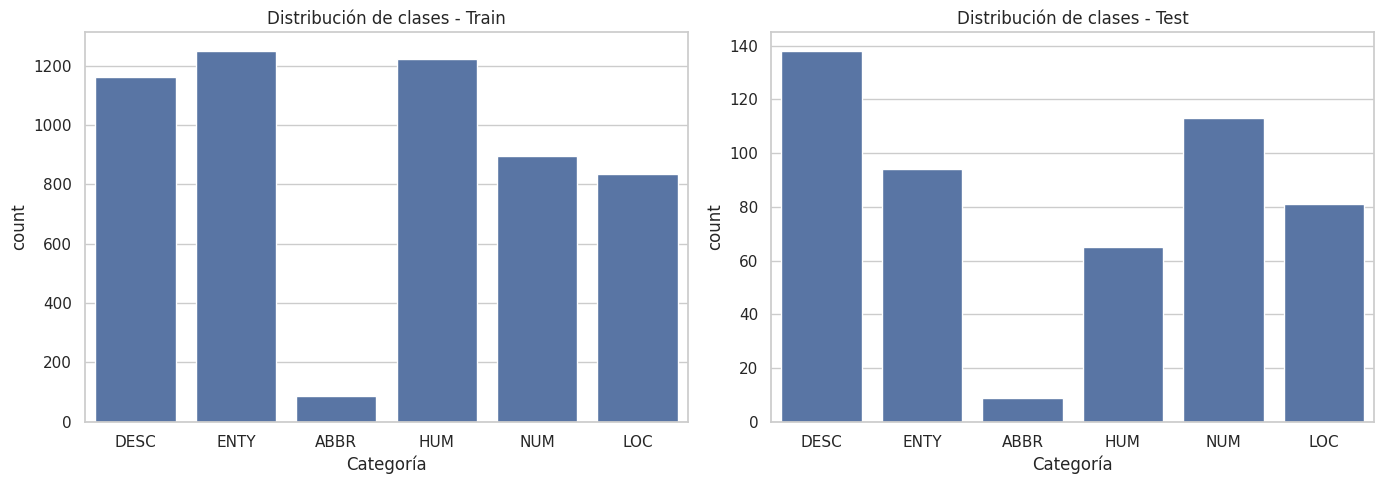

In [9]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train_df, x="label_name", order=LABEL_COARSE_MAP.values(), ax=axes[0])
axes[0].set_title("Distribución de clases - Train")
axes[0].set_xlabel("Categoría")

sns.countplot(data=test_df, x="label_name", order=LABEL_COARSE_MAP.values(), ax=axes[1])
axes[1].set_title("Distribución de clases - Test")
axes[1].set_xlabel("Categoría")
plt.tight_layout()
plt.show()


count    5452.000000
mean       10.204696
std         3.889021
min         3.000000
25%         7.000000
50%        10.000000
75%        12.000000
max        37.000000
Name: n_words, dtype: float64


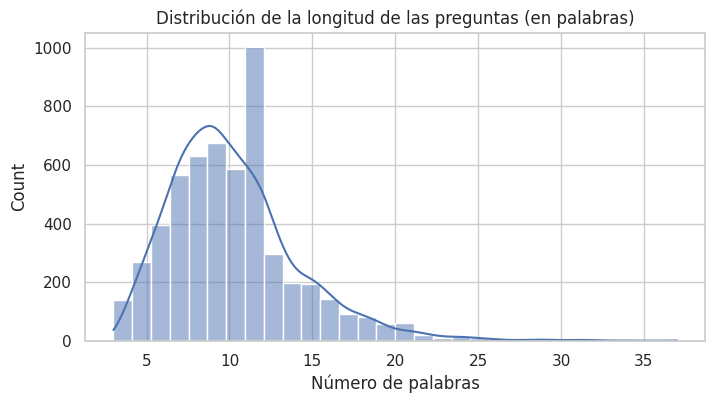

In [10]:
# Longitud de las preguntas
train_df["n_words"] = train_df["text"].str.split().str.len()
print(train_df["n_words"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(train_df["n_words"], bins=30, kde=True)
plt.title("Distribución de la longitud de las preguntas (en palabras)")
plt.xlabel("Número de palabras")
plt.show()


In [11]:

print("Número de subcategorías (label-fine):", train_df["label-fine"].nunique())


Número de subcategorías (label-fine): 47


## 4. Preprocesamiento

Se aplican las etapas descritas en la propuesta: limpieza de texto, conversión a
minúsculas, eliminación de caracteres irrelevantes y división en
entrenamiento / validación. El conjunto `test.csv` se reserva como conjunto de
prueba final, sin tocar hasta la evaluación final de cada modelo.

In [12]:
def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9À-ÿ\s'?.,]", " ", text)  # elimina caracteres especiales irrelevantes
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

train_df[["text", "clean_text"]].head()


,text,clean_text
0,How did serfdom develop in and then leave Russ...,how did serfdom develop in and then leave russ...
1,What films featured the character Popeye Doyle ?,what films featured the character popeye doyle ?
2,How can I find a list of celebrities ' real na...,how can i find a list of celebrities ' real na...
3,What fowl grabs the spotlight after the Chines...,what fowl grabs the spotlight after the chines...
4,What is the full form of .com ?,what is the full form of .com ?


In [13]:
# División 85/15 de train -> train/validación (test.csv se usa como test final)
train_split, val_split = train_test_split(
    train_df, test_size=0.15, random_state=SEED, stratify=train_df["label-coarse"]
)
print("Train:", train_split.shape, "Val:", val_split.shape, "Test:", test_df.shape)


Train: (4634, 6) Val: (818, 6) Test: (500, 5)


In [14]:
# Pesos de clase para mitigar el desequilibrio de la categoria ABBR (seccion 3.3).
# Se calculan a partir de la frecuencia inversa de cada clase en el conjunto de
# entrenamiento ("balanced": peso = n_muestras / (n_clases * frecuencia_clase)) y se
# aplican de forma consistente a los 5 modelos:
#   - Logistic Regression: class_weight="balanced" (equivalente a estos mismos pesos)
#   - LSTM / BiLSTM: nn.CrossEntropyLoss(weight=...)
#   - BERT / DistilBERT: Trainer personalizado con perdida ponderada (WeightedTrainer)
from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(sorted(LABEL_COARSE_MAP.keys())),
    y=train_split["label-coarse"].values,
)
class_weights_tensor = torch.tensor(class_weights_array, dtype=torch.float32).to(DEVICE)

print("Pesos de clase (balanced):")
for code, name in LABEL_COARSE_MAP.items():
    print(f"  {name} (codigo {code}): {class_weights_array[code]:.3f}")


Pesos de clase (balanced):
  DESC (codigo 0): 0.782
  ENTY (codigo 1): 0.727
  ABBR (codigo 2): 10.580
  HUM (codigo 3): 0.743
  NUM (codigo 4): 1.014
  LOC (codigo 5): 1.088


## 5. Modelo base: TF-IDF + Logistic Regression

Modelo tradicional de referencia (Machine Learning clásico)

In [15]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(train_split["clean_text"])
X_val_tfidf = tfidf.transform(val_split["clean_text"])
X_test_tfidf = tfidf.transform(test_df["clean_text"])

y_train = train_split["label-coarse"].values
y_val = val_split["label-coarse"].values
y_test = test_df["label-coarse"].values

logreg = LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced")  # ABBR: class weighting
logreg.fit(X_train_tfidf, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

In [16]:
def evaluate_predictions(y_true, y_pred, model_name, label_map=LABEL_COARSE_MAP):
    """Calcula y muestra las métricas estándar para un modelo."""
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    print(f"\n=== {model_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro)   : {recall:.4f}")
    print(f"F1-score (macro) : {f1:.4f}\n")
    print(classification_report(
        y_true, y_pred,
        target_names=[label_map[i] for i in sorted(label_map)],
        zero_division=0
    ))
    return {"model": model_name, "accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


def plot_confusion_matrix(y_true, y_pred, model_name, label_map=LABEL_COARSE_MAP):
    cm = confusion_matrix(y_true, y_pred)
    labels = [label_map[i] for i in sorted(label_map)]
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"Matriz de confusión - {model_name}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


results = []



=== Logistic Regression + TF-IDF ===
Accuracy : 0.7320
Precision (macro): 0.7322
Recall (macro)   : 0.7844
F1-score (macro) : 0.7016

              precision    recall  f1-score   support

        DESC       0.66      0.47      0.55       138
        ENTY       0.83      0.71      0.77        94
        ABBR       0.10      0.89      0.18         9
         HUM       0.92      0.91      0.91        65
         NUM       1.00      0.85      0.92       113
         LOC       0.89      0.88      0.88        81

    accuracy                           0.73       500
   macro avg       0.73      0.78      0.70       500
weighted avg       0.83      0.73      0.77       500



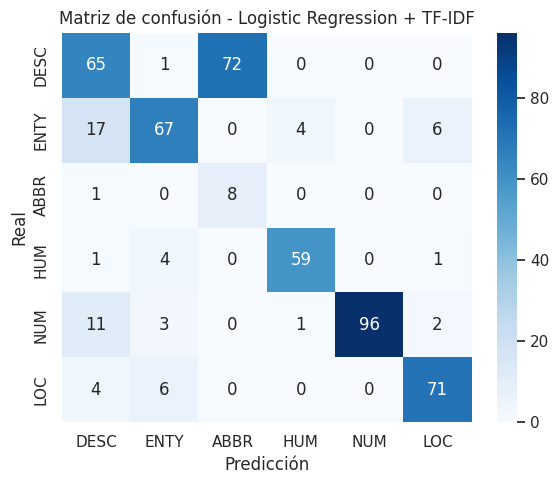

In [17]:
y_pred_logreg = logreg.predict(X_test_tfidf)
results.append(evaluate_predictions(y_test, y_pred_logreg, "Logistic Regression + TF-IDF"))
plot_confusion_matrix(y_test, y_pred_logreg, "Logistic Regression + TF-IDF")


## 6. Redes neuronales recurrentes: LSTM y BiLSTM

Implementación con PyTorch. Se construye un vocabulario propio a partir de los datos de
entrenamiento y se entrena un embedding desde cero.

In [18]:
from collections import Counter

def tokenize(text):
    return text.split()


counter = Counter()
for t in train_split["clean_text"]:
    counter.update(tokenize(t))

MIN_FREQ = 1
vocab = {"<pad>": 0, "<unk>": 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print("Tamaño del vocabulario:", VOCAB_SIZE)

def encode(text, max_len=30):
    tokens = tokenize(text)[:max_len]
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens]
    ids = ids + [vocab["<pad>"]] * (max_len - len(ids))
    return ids

MAX_LEN = 30


Tamaño del vocabulario: 7738


In [19]:
class QuestionDataset(Dataset):
    def __init__(self, df, max_len=MAX_LEN):
        self.texts = df["clean_text"].values
        self.labels = df["label-coarse"].values
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode(self.texts[idx], self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


train_ds = QuestionDataset(train_split)
val_ds = QuestionDataset(val_split)
test_ds = QuestionDataset(test_df)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)


In [20]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, n_classes=N_CLASSES,
                 bidirectional=False, n_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=n_layers,
            bidirectional=bidirectional, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        mult = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * mult, n_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        if self.lstm.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_cat = hidden[-1]
        out = self.dropout(hidden_cat)
        return self.fc(out)


In [21]:
def train_torch_model(model, train_loader, val_loader, n_epochs=10, lr=1e-3, patience=3, class_weights=None):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(weight=class_weights)  # ABBR: class weighting

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(n_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            train_correct += (logits.argmax(1) == y).sum().item()
            train_total += x.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item() * x.size(0)
                val_correct += (logits.argmax(1) == y).sum().item()
                val_total += x.size(0)

        train_loss /= train_total
        val_loss /= val_total
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{n_epochs} - "
              f"train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} - "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping activado.")
                break

    model.load_state_dict(best_state)
    return model, history


def plot_learning_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Época")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Val")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def predict_torch_model(model, loader):
    model.eval()
    preds, trues = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        logits = model(x)
        preds.extend(logits.argmax(1).cpu().numpy())
        trues.extend(y.numpy())
    return np.array(trues), np.array(preds)


Epoch 1/15 - train_loss: 1.7907 train_acc: 0.2095 - val_loss: 1.7807 val_acc: 0.2249
Epoch 2/15 - train_loss: 1.7860 train_acc: 0.2104 - val_loss: 1.7842 val_acc: 0.2262
Epoch 3/15 - train_loss: 1.7778 train_acc: 0.2195 - val_loss: 1.7808 val_acc: 0.2200
Epoch 4/15 - train_loss: 1.6809 train_acc: 0.2385 - val_loss: 1.5832 val_acc: 0.2372
Epoch 5/15 - train_loss: 1.3652 train_acc: 0.3714 - val_loss: 1.3155 val_acc: 0.3924
Epoch 6/15 - train_loss: 1.0196 train_acc: 0.5278 - val_loss: 1.1326 val_acc: 0.5244
Epoch 7/15 - train_loss: 0.7536 train_acc: 0.6599 - val_loss: 0.9396 val_acc: 0.5917
Epoch 8/15 - train_loss: 0.5579 train_acc: 0.7723 - val_loss: 0.9543 val_acc: 0.6687
Epoch 9/15 - train_loss: 0.4313 train_acc: 0.8382 - val_loss: 0.9350 val_acc: 0.6883
Epoch 10/15 - train_loss: 0.3179 train_acc: 0.8886 - val_loss: 0.8317 val_acc: 0.7286
Epoch 11/15 - train_loss: 0.2793 train_acc: 0.9061 - val_loss: 0.9366 val_acc: 0.7531
Epoch 12/15 - train_loss: 0.1861 train_acc: 0.9409 - val_loss: 

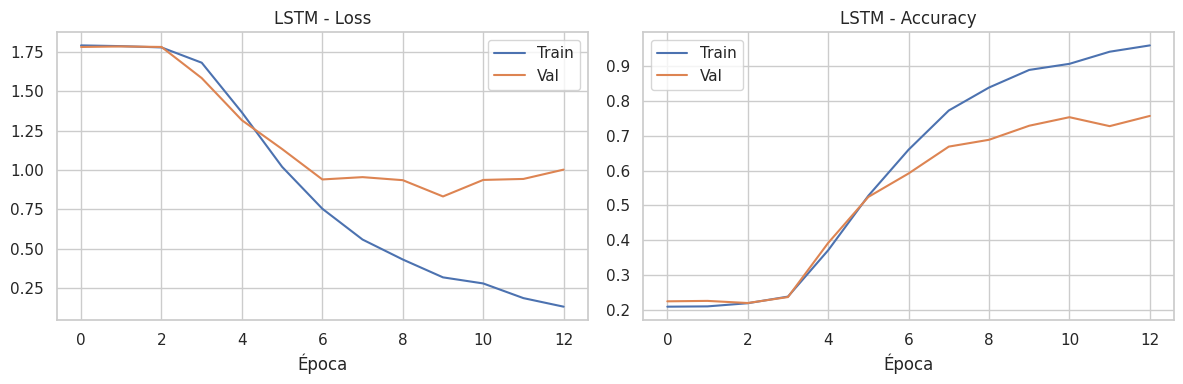


=== LSTM ===
Accuracy : 0.7080
Precision (macro): 0.6771
Recall (macro)   : 0.7673
F1-score (macro) : 0.6675

              precision    recall  f1-score   support

        DESC       0.75      0.58      0.66       138
        ENTY       0.72      0.61      0.66        94
        ABBR       0.16      1.00      0.27         9
         HUM       0.85      0.82      0.83        65
         NUM       0.86      0.79      0.82       113
         LOC       0.71      0.81      0.76        81

    accuracy                           0.71       500
   macro avg       0.68      0.77      0.67       500
weighted avg       0.77      0.71      0.73       500



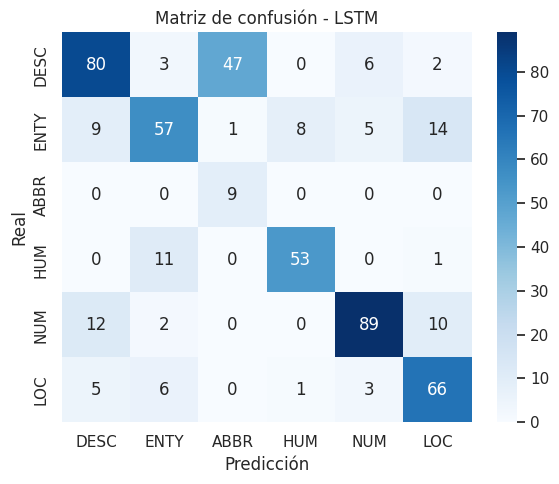

In [22]:
# --- LSTM ---
lstm_model = LSTMClassifier(VOCAB_SIZE, bidirectional=False)
lstm_model, lstm_history = train_torch_model(
    lstm_model, train_loader, val_loader, n_epochs=15, lr=1e-3,
    class_weights=class_weights_tensor,  # ABBR: class weighting
)
plot_learning_curves(lstm_history, "LSTM")

y_true_lstm, y_pred_lstm = predict_torch_model(lstm_model, test_loader)
results.append(evaluate_predictions(y_true_lstm, y_pred_lstm, "LSTM"))
plot_confusion_matrix(y_true_lstm, y_pred_lstm, "LSTM")


Epoch 1/15 - train_loss: 1.1942 train_acc: 0.5550 - val_loss: 0.7980 val_acc: 0.6846
Epoch 2/15 - train_loss: 0.6497 train_acc: 0.7415 - val_loss: 0.6529 val_acc: 0.7445
Epoch 3/15 - train_loss: 0.4068 train_acc: 0.8364 - val_loss: 0.6346 val_acc: 0.7751
Epoch 4/15 - train_loss: 0.2527 train_acc: 0.9053 - val_loss: 0.6646 val_acc: 0.7946
Epoch 5/15 - train_loss: 0.1437 train_acc: 0.9543 - val_loss: 0.7098 val_acc: 0.7848
Epoch 6/15 - train_loss: 0.0713 train_acc: 0.9799 - val_loss: 0.8283 val_acc: 0.7873
Early stopping activado.


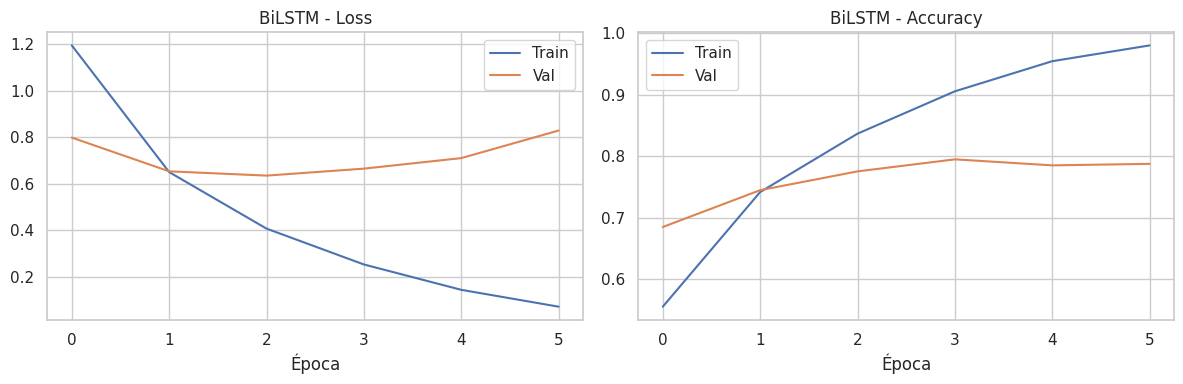


=== BiLSTM ===
Accuracy : 0.8380
Precision (macro): 0.8135
Recall (macro)   : 0.8211
F1-score (macro) : 0.8132

              precision    recall  f1-score   support

        DESC       0.91      0.95      0.93       138
        ENTY       0.74      0.54      0.63        94
        ABBR       0.78      0.78      0.78         9
         HUM       0.76      0.85      0.80        65
         NUM       0.92      0.88      0.90       113
         LOC       0.77      0.93      0.84        81

    accuracy                           0.84       500
   macro avg       0.81      0.82      0.81       500
weighted avg       0.84      0.84      0.83       500



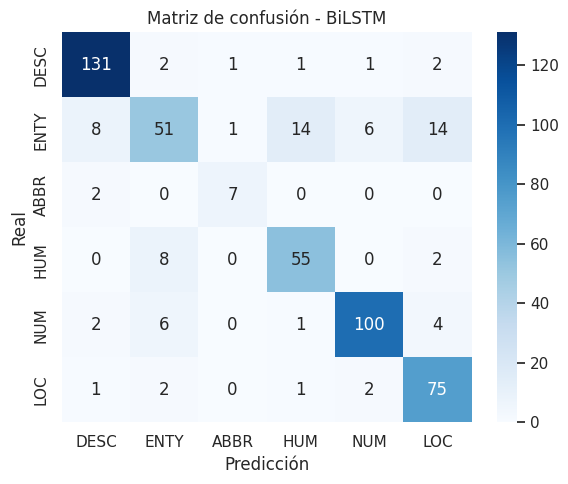

In [23]:
# --- BiLSTM ---
bilstm_model = LSTMClassifier(VOCAB_SIZE, bidirectional=True)
bilstm_model, bilstm_history = train_torch_model(
    bilstm_model, train_loader, val_loader, n_epochs=15, lr=1e-3,
    class_weights=class_weights_tensor,  # ABBR: class weighting
)
plot_learning_curves(bilstm_history, "BiLSTM")

y_true_bilstm, y_pred_bilstm = predict_torch_model(bilstm_model, test_loader)
results.append(evaluate_predictions(y_true_bilstm, y_pred_bilstm, "BiLSTM"))
plot_confusion_matrix(y_true_bilstm, y_pred_bilstm, "BiLSTM")


## 7. Modelos basados en Transformers: BERT y DistilBERT

Fine-tuning mediante transferencia de aprendizaje mediante la librería
Hugging Face `transformers`, tal como se describe en las secciones 4.b y 4.c
de la propuesta. Se recomienda ejecutar esta sección con GPU (Google Colab).

In [24]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback, set_seed
)
from datasets import Dataset as HFDataset
import evaluate

# Datasets de Hugging Face a partir de los splits ya creados
hf_train = HFDataset.from_pandas(train_split[["clean_text", "label-coarse"]].rename(
    columns={"clean_text": "text", "label-coarse": "label"}
).reset_index(drop=True))
hf_val = HFDataset.from_pandas(val_split[["clean_text", "label-coarse"]].rename(
    columns={"clean_text": "text", "label-coarse": "label"}
).reset_index(drop=True))
hf_test = HFDataset.from_pandas(test_df[["clean_text", "label-coarse"]].rename(
    columns={"clean_text": "text", "label-coarse": "label"}
).reset_index(drop=True))

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1": f1}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [25]:
class WeightedTrainer(Trainer):
    """Trainer de Hugging Face con CrossEntropyLoss ponderada por clase, para
    mitigar el desequilibrio de la categoria minoritaria ABBR (seccion 3.3),
    de forma consistente con el resto de modelos (LogReg, LSTM, BiLSTM)."""

    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss


def fine_tune_transformer(model_checkpoint, output_dir, n_epochs=4, lr=2e-5, batch_size=16, seed=SEED):
    """Fine-tuning de un modelo de la familia BERT con:
      - Cabeza de clasificacion por defecto de AutoModelForSequenceClassification
        (capa de pooling + dropout + capa lineal de hidden_size -> N_CLASSES).
      - Warmup lineal (10% de los pasos) seguido de decaimiento lineal del learning
        rate, tal como recomienda la literatura para el fine-tuning de transformers.
      - Perdida ponderada por clase (WeightedTrainer) para mitigar el desequilibrio
        de la categoria ABBR.
    """
    set_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

    def tokenize_fn(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=32)

    train_tok = hf_train.map(tokenize_fn, batched=True)
    val_tok = hf_val.map(tokenize_fn, batched=True)
    test_tok = hf_test.map(tokenize_fn, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint, num_labels=N_CLASSES
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=n_epochs,
        weight_decay=0.01,
        warmup_ratio=0.1,             # NUEVO: 10% de los pasos en fase de calentamiento
        lr_scheduler_type="linear",   # decaimiento lineal tras el warmup
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
        report_to="none",
        disable_tqdm=True,
        seed=seed,
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
        class_weights=class_weights_tensor,
    )

    trainer.train()

    test_preds = trainer.predict(test_tok)
    y_pred = np.argmax(test_preds.predictions, axis=-1)
    y_true = np.array(test_tok["label"])

    return trainer, y_true, y_pred


def plot_transformer_learning_curves(trainer, model_name):
    """Extrae loss de entrenamiento/validacion y accuracy de validacion del
    historial del Trainer (TrainerState.log_history) y genera las curvas de
    aprendizaje, de forma analoga a plot_learning_curves() para LSTM/BiLSTM
    (seccion 6.2). La accuracy de entrenamiento no se reporta porque compute_metrics
    solo se invoca sobre el conjunto de validacion en cada epoca."""
    history = trainer.state.log_history
    train_loss = [(h["epoch"], h["loss"]) for h in history if "loss" in h]
    val_loss = [(h["epoch"], h["eval_loss"]) for h in history if "eval_loss" in h]
    val_acc = [(h["epoch"], h["eval_accuracy"]) for h in history if "eval_accuracy" in h]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    if train_loss:
        epochs_tr, losses_tr = zip(*train_loss)
        axes[0].plot(epochs_tr, losses_tr, label="Train")
    if val_loss:
        epochs_vl, losses_vl = zip(*val_loss)
        axes[0].plot(epochs_vl, losses_vl, label="Val", marker="o")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Epoca")
    axes[0].legend()

    if val_acc:
        epochs_acc, accs = zip(*val_acc)
        axes[1].plot(epochs_acc, accs, label="Val", color="darkorange", marker="o")
    axes[1].set_title(f"{model_name} - Accuracy (validacion)")
    axes[1].set_xlabel("Epoca")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4634 [00:00<?, ? examples/s]

...

{'loss': '0.2559', 'grad_norm': '15.87', 'learning_rate': '2.687e-05', 'epoch': '2.069'}
{'loss': '0.1445', 'grad_norm': '20.01', 'learning_rate': '2.447e-05', 'epoch': '2.241'}
{'loss': '0.03701', 'grad_norm': '0.4957', 'learning_rate': '2.208e-05', 'epoch': '2.414'}
{'loss': '0.0366', 'grad_norm': '0.07767', 'learning_rate': '1.968e-05', 'epoch': '2.586'}
{'loss': '0.038', 'grad_norm': '0.03195', 'learning_rate': '1.729e-05', 'epoch': '2.759'}
{'loss': '0.02743', 'grad_norm': '0.04503', 'learning_rate': '1.489e-05', 'epoch': '2.931'}
{'eval_loss': '0.331', 'eval_accuracy': '0.9401', 'eval_f1': '0.9285', 'eval_runtime': '0.8546', 'eval_samples_per_second': '957.2', 'eval_steps_per_second': '60.85', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.0884', 'grad_norm': '0.0521', 'learning_rate': '1.25e-05', 'epoch': '3.103'}
{'loss': '0.01231', 'grad_norm': '0.02985', 'learning_rate': '1.011e-05', 'epoch': '3.276'}
{'loss': '0.03817', 'grad_norm': '0.0645', 'learning_rate': '7.711e-06', 'epoch': '3.448'}
{'loss': '0.04942', 'grad_norm': '0.1267', 'learning_rate': '5.316e-06', 'epoch': '3.621'}
{'loss': '0.02821', 'grad_norm': '0.03126', 'learning_rate': '2.921e-06', 'epoch': '3.793'}
{'loss': '0.0189', 'grad_norm': '0.03015', 'learning_rate': '5.268e-07', 'epoch': '3.966'}
{'eval_loss': '0.3489', 'eval_accuracy': '0.9401', 'eval_f1': '0.9191', 'eval_runtime': '0.8501', 'eval_samples_per_second': '962.3', 'eval_steps_per_second': '61.17', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '91.81', 'train_samples_per_second': '201.9', 'train_steps_per_second': '12.63', 'train_loss': '0.2643', 'epoch': '4'}

=== DistilBERT ===
Accuracy : 0.9740
Precision (macro): 0.9798
Recall (macro)   : 0.9772
F1-score (macro) : 0.9781

              precision    recall  f1-score   support

        DESC       0.96      0.99      0.98       138
        ENTY       0.99      0.90      0.94        94
        ABBR       1.00      1.00      1.00         9
         HUM       0.98      1.00      0.99        65
         NUM       0.97      0.99      0.98       113
         LOC       0.98      0.98      0.98        81

    accuracy                           0.97       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.97      0.97      0.97       500



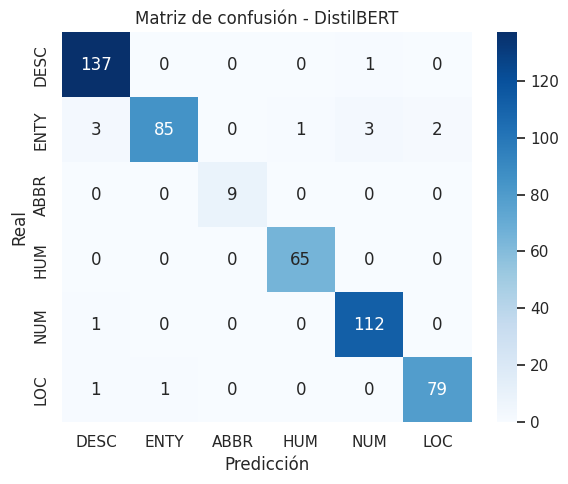

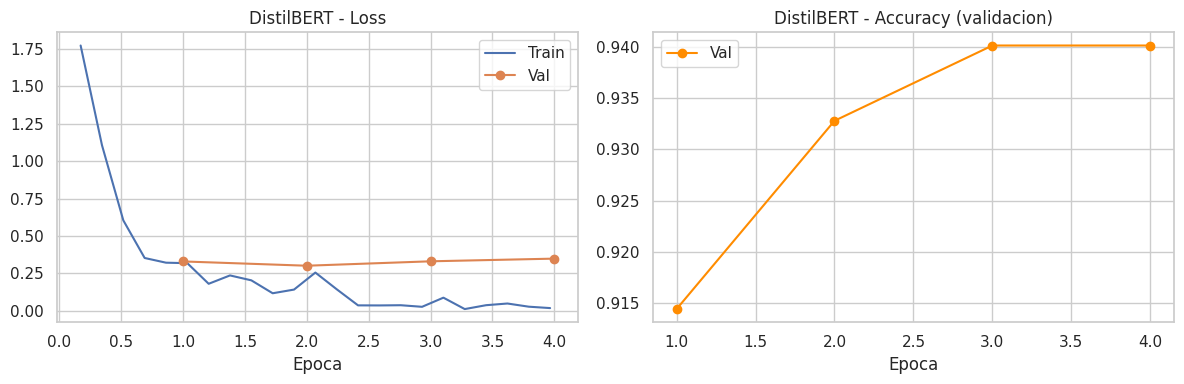

In [26]:
# --- DistilBERT ---
distilbert_trainer, y_true_distil, y_pred_distil = fine_tune_transformer(
    "distilbert-base-uncased", output_dir="./distilbert_output", n_epochs=4, lr=5e-5
)
results.append(evaluate_predictions(y_true_distil, y_pred_distil, "DistilBERT"))
plot_confusion_matrix(y_true_distil, y_pred_distil, "DistilBERT")
plot_transformer_learning_curves(distilbert_trainer, "DistilBERT")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4634 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.1375', 'grad_norm': '0.1357', 'learning_rate': '5e-06', 'epoch': '3.103'}
{'loss': '0.03928', 'grad_norm': '0.08077', 'learning_rate': '4.042e-06', 'epoch': '3.276'}
{'loss': '0.03782', 'grad_norm': '22.71', 'learning_rate': '3.084e-06', 'epoch': '3.448'}
{'loss': '0.04577', 'grad_norm': '0.4626', 'learning_rate': '2.126e-06', 'epoch': '3.621'}
{'loss': '0.08317', 'grad_norm': '1.21', 'learning_rate': '1.169e-06', 'epoch': '3.793'}
{'loss': '0.01627', 'grad_norm': '21.14', 'learning_rate': '2.107e-07', 'epoch': '3.966'}
{'eval_loss': '0.3108', 'eval_accuracy': '0.9474', 'eval_f1': '0.9246', 'eval_runtime': '1.8', 'eval_samples_per_second': '454.4', 'eval_steps_per_second': '28.89', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

{'train_runtime': '186', 'train_samples_per_second': '99.67', 'train_steps_per_second': '6.238', 'train_loss': '0.3543', 'epoch': '4'}

=== BERT ===
Accuracy : 0.9680
Precision (macro): 0.9727
Recall (macro)   : 0.9541
F1-score (macro) : 0.9625

              precision    recall  f1-score   support

        DESC       0.96      0.99      0.98       138
        ENTY       0.97      0.88      0.92        94
        ABBR       1.00      0.89      0.94         9
         HUM       0.96      0.98      0.97        65
         NUM       0.98      1.00      0.99       113
         LOC       0.98      0.98      0.98        81

    accuracy                           0.97       500
   macro avg       0.97      0.95      0.96       500
weighted avg       0.97      0.97      0.97       500



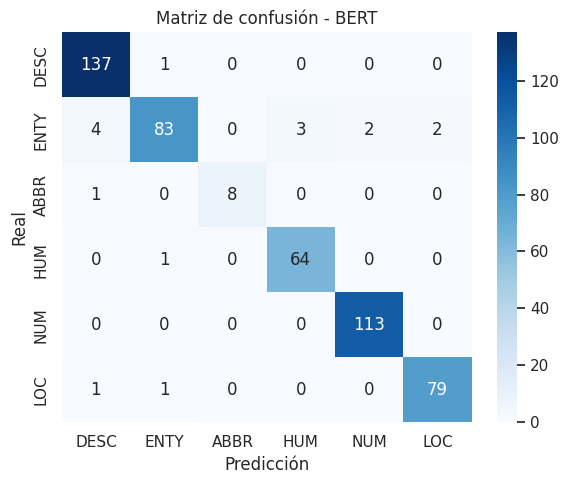

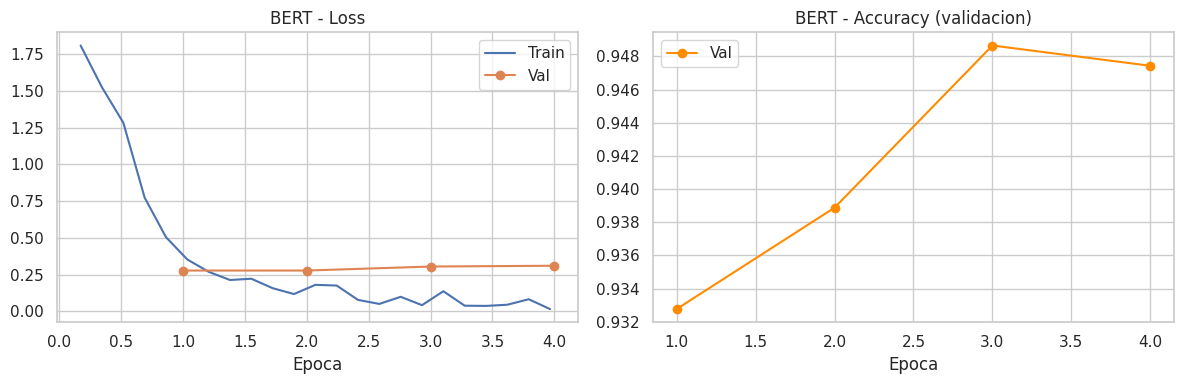

In [27]:
# --- BERT ---
bert_trainer, y_true_bert, y_pred_bert = fine_tune_transformer(
    "bert-base-uncased", output_dir="./bert_output", n_epochs=4, lr=2e-5
)
results.append(evaluate_predictions(y_true_bert, y_pred_bert, "BERT"))
plot_confusion_matrix(y_true_bert, y_pred_bert, "BERT")
plot_transformer_learning_curves(bert_trainer, "BERT")


## 7.1. Significancia estadistica (BERT vs DistilBERT)

Los resultados de la seccion anterior corresponden a una unica ejecucion por
modelo con una semilla aleatoria fija. Para comprobar si la diferencia de
rendimiento entre BERT y DistilBERT es estadisticamente significativa o si
podria deberse al azar de una unica ejecucion, se repite el fine-tuning de
ambos modelos con 5 semillas aleatorias distintas y se calculan la media y la
desviacion tipica de Accuracy y F1-Score macro, junto con un test t de
Student sobre las 5 ejecuciones de cada modelo.

Esta seccion esta dividida en varias celdas independientes (funciones
auxiliares, DistilBERT, BERT y comparacion final) para que, si la ejecucion
se interrumpe en mitad de un modelo (desconexion de Colab, limite de tiempo,
etc.), no se pierda el trabajo ya realizado en el otro. Los resultados de
cada semilla se guardan en disco (`seed_results.json`) en cuanto se
completan; si una celda se interrumpe y se vuelve a ejecutar, las semillas ya
guardadas se detectan automaticamente y no se repiten.

**ADVERTENCIA:** entrenar 5 semillas de un modelo transformer puede tardar
entre 15 y 30 minutos en una GPU T4 de Colab. Si se dispone de poco tiempo,
se puede reducir el numero de semillas (por ejemplo, a 3) o el numero de
epocas, pasando `seeds=(0, 1, 2)` y/o `n_epochs=2` en la llamada
correspondiente.


In [28]:
import os
import json
from scipy import stats as scipy_stats

RESULTS_PATH = "seed_results.json"

def load_partial_results():
    if os.path.exists(RESULTS_PATH):
        with open(RESULTS_PATH) as f:
            return json.load(f)
    return {}

def save_partial_results(results):
    with open(RESULTS_PATH, "w") as f:
        json.dump(results, f, indent=2)


def run_multiple_seeds_transformer(model_checkpoint, output_dir, n_epochs=4, lr=2e-5,
                                    batch_size=16, seeds=(0, 1, 2, 3, 4)):
    """Repite el fine-tuning del modelo con distintas semillas aleatorias y
    devuelve la media y la desviacion tipica de accuracy y F1-Score macro
    sobre el conjunto de test, para evaluar la significancia estadistica de
    las diferencias de rendimiento observadas (seccion 6.3bis).

    Version resiliente: guarda los resultados en disco (RESULTS_PATH) tras
    cada semilla. Si la ejecucion se interrumpe (desconexion de Colab, Stop
    manual, limite de tiempo, etc.), basta con volver a ejecutar la misma
    celda: las semillas ya completadas se detectan y no se repiten."""
    all_results = load_partial_results()
    key = model_checkpoint
    if key not in all_results:
        all_results[key] = {"accuracy_runs": [], "f1_runs": [], "completed_seeds": []}

    for seed in seeds:
        if seed in all_results[key]["completed_seeds"]:
            print(f"--- {model_checkpoint} | semilla {seed} ya completada, se omite ---", flush=True)
            continue

        print(f"\n--- {model_checkpoint} | semilla {seed} | iniciando ---", flush=True)
        _, y_true, y_pred = fine_tune_transformer(
            model_checkpoint, output_dir=f"{output_dir}_seed{seed}",
            n_epochs=n_epochs, lr=lr, batch_size=batch_size, seed=seed,
        )
        acc = accuracy_score(y_true, y_pred)
        _, _, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)

        all_results[key]["accuracy_runs"].append(acc)
        all_results[key]["f1_runs"].append(f1)
        all_results[key]["completed_seeds"].append(seed)
        save_partial_results(all_results)  # se guarda inmediatamente tras cada semilla

        print(f"  accuracy={acc:.4f}  f1_macro={f1:.4f}  (guardado en {RESULTS_PATH})", flush=True)

    accs = all_results[key]["accuracy_runs"]
    f1s = all_results[key]["f1_runs"]
    return {
        "model": model_checkpoint,
        "accuracy_mean": float(np.mean(accs)), "accuracy_std": float(np.std(accs)),
        "f1_mean": float(np.mean(f1s)), "f1_std": float(np.std(f1s)),
        "accuracy_runs": accs, "f1_runs": f1s,
    }


In [29]:
# Entrena (o reanuda) las 5 semillas de DistilBERT. Si esta celda se
# interrumpe, los resultados ya completados quedan guardados en disco: basta
# con volver a ejecutar esta misma celda para continuar donde se quedo, sin
# afectar a la celda de BERT ni repetir entrenamientos ya hechos.
stats_distilbert = run_multiple_seeds_transformer(
    "distilbert-base-uncased", "./distilbert_stats", lr=5e-5
)
print("\nResumen DistilBERT (5 semillas):")
print(stats_distilbert)



--- distilbert-base-uncased | semilla 0 | iniciando ---


Map:   0%|          | 0/4634 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

{'loss': '0.1243', 'grad_norm': '0.5588', 'learning_rate': '2.687e-05', 'epoch': '2.069'}
{'loss': '0.061', 'grad_norm': '8.25', 'learning_rate': '2.447e-05', 'epoch': '2.241'}
{'loss': '0.06113', 'grad_norm': '0.05375', 'learning_rate': '2.208e-05', 'epoch': '2.414'}
{'loss': '0.03938', 'grad_norm': '0.03631', 'learning_rate': '1.968e-05', 'epoch': '2.586'}
{'loss': '0.07026', 'grad_norm': '0.3102', 'learning_rate': '1.729e-05', 'epoch': '2.759'}
{'loss': '0.08352', 'grad_norm': '0.03824', 'learning_rate': '1.489e-05', 'epoch': '2.931'}
{'eval_loss': '0.3366', 'eval_accuracy': '0.9511', 'eval_f1': '0.9202', 'eval_runtime': '0.9478', 'eval_samples_per_second': '863.1', 'eval_steps_per_second': '54.87', 'epoch': '3'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.04888', 'grad_norm': '0.03129', 'learning_rate': '1.25e-05', 'epoch': '3.103'}
{'loss': '0.02188', 'grad_norm': '0.01924', 'learning_rate': '1.011e-05', 'epoch': '3.276'}
{'loss': '0.05374', 'grad_norm': '0.03843', 'learning_rate': '7.711e-06', 'epoch': '3.448'}
{'loss': '0.03011', 'grad_norm': '0.0286', 'learning_rate': '5.316e-06', 'epoch': '3.621'}
{'loss': '0.03543', 'grad_norm': '105.1', 'learning_rate': '2.921e-06', 'epoch': '3.793'}
{'loss': '0.006071', 'grad_norm': '0.09911', 'learning_rate': '5.268e-07', 'epoch': '3.966'}
{'eval_loss': '0.336', 'eval_accuracy': '0.9511', 'eval_f1': '0.9236', 'eval_runtime': '0.9374', 'eval_samples_per_second': '872.6', 'eval_steps_per_second': '55.47', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '167', 'train_samples_per_second': '111', 'train_steps_per_second': '6.946', 'train_loss': '0.2534', 'epoch': '4'}
  accuracy=0.9660  f1_macro=0.9642  (guardado en seed_results.json)

Resumen DistilBERT (5 semillas):
{'model': 'distilbert-base-uncased', 'accuracy_mean': 0.97, 'accuracy_std': 0.0033466401061363056, 'f1_mean': 0.9663661540127085, 'f1_std': 0.0028887227995335195, 'accuracy_runs': [0.974, 0.968, 0.974, 0.968, 0.966], 'f1_runs': [0.9696537043646721, 0.9630081912481083, 0.9699827418462822, 0.9649620569536164, 0.9642240756508641]}


In [30]:
# Entrena (o reanuda) las 5 semillas de BERT. Totalmente independiente de la
# celda anterior: si DistilBERT ya ha terminado (o si esta celda se ejecuta
# antes), no se ven afectados entre si.
stats_bert = run_multiple_seeds_transformer(
    "bert-base-uncased", "./bert_stats", lr=2e-5
)
print("\nResumen BERT (5 semillas):")
print(stats_bert)



--- bert-base-uncased | semilla 0 | iniciando ---


Map:   0%|          | 0/4634 [00:00<?, ? examples/s]

Map:   0%|          | 0/818 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '0.03347', 'grad_norm': '0.07219', 'learning_rate': '5e-06', 'epoch': '3.103'}
{'loss': '0.02739', 'grad_norm': '0.1676', 'learning_rate': '4.042e-06', 'epoch': '3.276'}
{'loss': '0.0625', 'grad_norm': '0.6021', 'learning_rate': '3.084e-06', 'epoch': '3.448'}
{'loss': '0.09194', 'grad_norm': '0.5853', 'learning_rate': '2.126e-06', 'epoch': '3.621'}
{'loss': '0.06835', 'grad_norm': '51.21', 'learning_rate': '1.169e-06', 'epoch': '3.793'}
{'loss': '0.07557', 'grad_norm': '0.2502', 'learning_rate': '2.107e-07', 'epoch': '3.966'}
{'eval_loss': '0.3143', 'eval_accuracy': '0.9499', 'eval_f1': '0.9265', 'eval_runtime': '1.865', 'eval_samples_per_second': '438.7', 'eval_steps_per_second': '27.89', 'epoch': '4'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

{'train_runtime': '196.8', 'train_samples_per_second': '94.18', 'train_steps_per_second': '5.894', 'train_loss': '0.3434', 'epoch': '4'}
  accuracy=0.9740  f1_macro=0.9681  (guardado en seed_results.json)

Resumen BERT (5 semillas):
{'model': 'bert-base-uncased', 'accuracy_mean': 0.9692000000000001, 'accuracy_std': 0.004118252056394804, 'f1_mean': 0.9641269256707032, 'f1_std': 0.003112989052604772, 'accuracy_runs': [0.962, 0.972, 0.97, 0.968, 0.974], 'f1_runs': [0.9590896090586951, 0.9663584282059873, 0.964557539431473, 0.9625674250376487, 0.9680616266197122]}


In [31]:
# Esta celda puede ejecutarse de forma independiente, incluso si el entorno
# se ha reiniciado entre medias: lee los resultados directamente del fichero
# seed_results.json en lugar de depender de las variables en memoria, siempre
# que ambos modelos (BERT y DistilBERT) hayan completado sus 5 semillas.
all_results = load_partial_results()

def _summarize(model_key):
    accs = all_results[model_key]["accuracy_runs"]
    f1s = all_results[model_key]["f1_runs"]
    return {
        "model": model_key,
        "accuracy_mean": float(np.mean(accs)), "accuracy_std": float(np.std(accs)),
        "f1_mean": float(np.mean(f1s)), "f1_std": float(np.std(f1s)),
        "accuracy_runs": accs, "f1_runs": f1s,
    }

stats_bert = _summarize("bert-base-uncased")
stats_distilbert = _summarize("distilbert-base-uncased")

stats_df = pd.DataFrame([stats_bert, stats_distilbert])[
    ["model", "accuracy_mean", "accuracy_std", "f1_mean", "f1_std"]
]
print("=== Resultados de 5 ejecucione ===")
print(stats_df.to_string(index=False))

# Test t de Student para muestras independientes sobre las 5 ejecuciones de
# cada modelo: responde a si la diferencia de accuracy entre BERT y
# DistilBERT es estadisticamente significativa (p < 0.05) o no.
t_stat, p_value = scipy_stats.ttest_ind(stats_bert["accuracy_runs"], stats_distilbert["accuracy_runs"])
print(f"\nTest t (BERT vs DistilBERT, accuracy): t={t_stat:.3f}, p-valor={p_value:.4f}")
if p_value < 0.05:
    print("=> La diferencia es  significativa (p < 0.05).")
else:
    print("=> La diferencia NO es significativa (p >= 0.05).")


=== Resultados de 5 ejecucione ===
                  model  accuracy_mean  accuracy_std  f1_mean   f1_std
      bert-base-uncased         0.9692      0.004118 0.964127 0.003113
distilbert-base-uncased         0.9700      0.003347 0.966366 0.002889

Test t (BERT vs DistilBERT, accuracy): t=-0.302, p-valor=0.7707
=> La diferencia NO es significativa (p >= 0.05).


## 8. Comparación final de modelos

Tabla y gráfico comparativo de Accuracy, Precision, Recall y F1-Score
para todos los modelos evaluados

In [32]:
results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
results_df


,model,accuracy,precision,recall,f1
0,DistilBERT,0.974,0.979806,0.977245,0.978143
1,BERT,0.968,0.972717,0.954091,0.962454
2,BiLSTM,0.838,0.813524,0.821107,0.813190
3,Logistic Regression + TF-IDF,0.732,0.732184,0.784410,0.701565
4,LSTM,0.708,0.677121,0.767317,0.667461


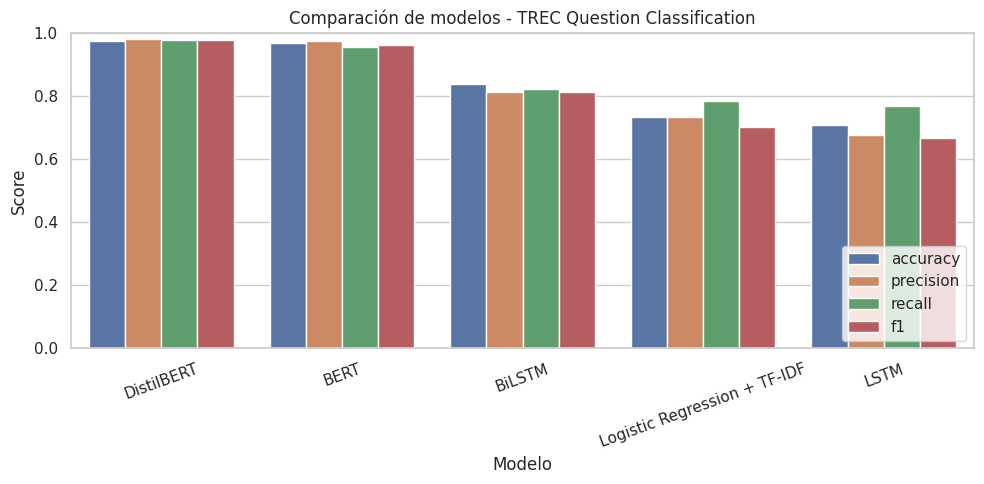

In [33]:
results_melted = results_df.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(10, 5))
sns.barplot(data=results_melted, x="model", y="score", hue="metric")
plt.title("Comparación de modelos - TREC Question Classification")
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 9. Criterio de validez para producción

Para validar un modelo se considera apto para
producción si:

- Accuracy > 90%
- F1-Score (macro) > 0.90
- Rendimiento estable entre validación y test (sin sobreajuste significativo)


In [34]:
PROD_ACC_THRESHOLD = 0.90
PROD_F1_THRESHOLD = 0.90

results_df["apto_para_produccion"] = (
    (results_df["accuracy"] > PROD_ACC_THRESHOLD) &
    (results_df["f1"] > PROD_F1_THRESHOLD)
)
results_df


,model,accuracy,precision,recall,f1,apto_para_produccion
0,DistilBERT,0.974,0.979806,0.977245,0.978143,True
1,BERT,0.968,0.972717,0.954091,0.962454,True
2,BiLSTM,0.838,0.813524,0.821107,0.813190,False
3,Logistic Regression + TF-IDF,0.732,0.732184,0.784410,0.701565,False
4,LSTM,0.708,0.677121,0.767317,0.667461,False


## 10. Guardado del mejor modelo

El mejor modelo (según F1-Score macro) se guarda para su posterior despliegue,
en formato compatible con Hugging Face (`.bin`/`.safetensors` + tokenizer) o
PyTorch (`.pt`), según corresponda (sección 8.b de la propuesta).

In [36]:
best_model_name = results_df.iloc[0]["model"]
print("Mejor modelo:", best_model_name)

distilbert_trainer.save_model("./best_model_distilbert")
#tokenizer.save_pretrained("./best_model_distilbert")
#torch.save(bilstm_model.state_dict(), "bilstm_model.pt")


Mejor modelo: DistilBERT


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]